# Unit I: Climate Change Module



---

# Part 1: The code you didn't write

Mauna Loa monthly CO2: <https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt>

Below is working code for that file. It runs and it produces a plausible plot.

In [38]:
import pandas as pd
from plotnine import *

In [39]:
columns = ['year', 'month', 'decimal_date', 'average', 'smooth', 'std_days', 'uncertainty', 'empty']
df = pd.read_csv("https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt",
                  sep = '\s+',
                  comment = '#',
                  header = None,
                  names = columns
                  )
df

<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_6942/60946832.py:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.


,year,month,decimal_date,average,smooth,std_days,uncertainty,empty
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
817,2026,4,2026.2917,431.12,428.61,23,1.16,0.46
818,2026,5,2026.3750,432.34,429.06,19,0.64,0.28
819,2026,6,2026.4583,431.43,428.99,19,0.27,0.12
820,2026,7,2026.5417,429.13,428.78,21,0.61,0.26


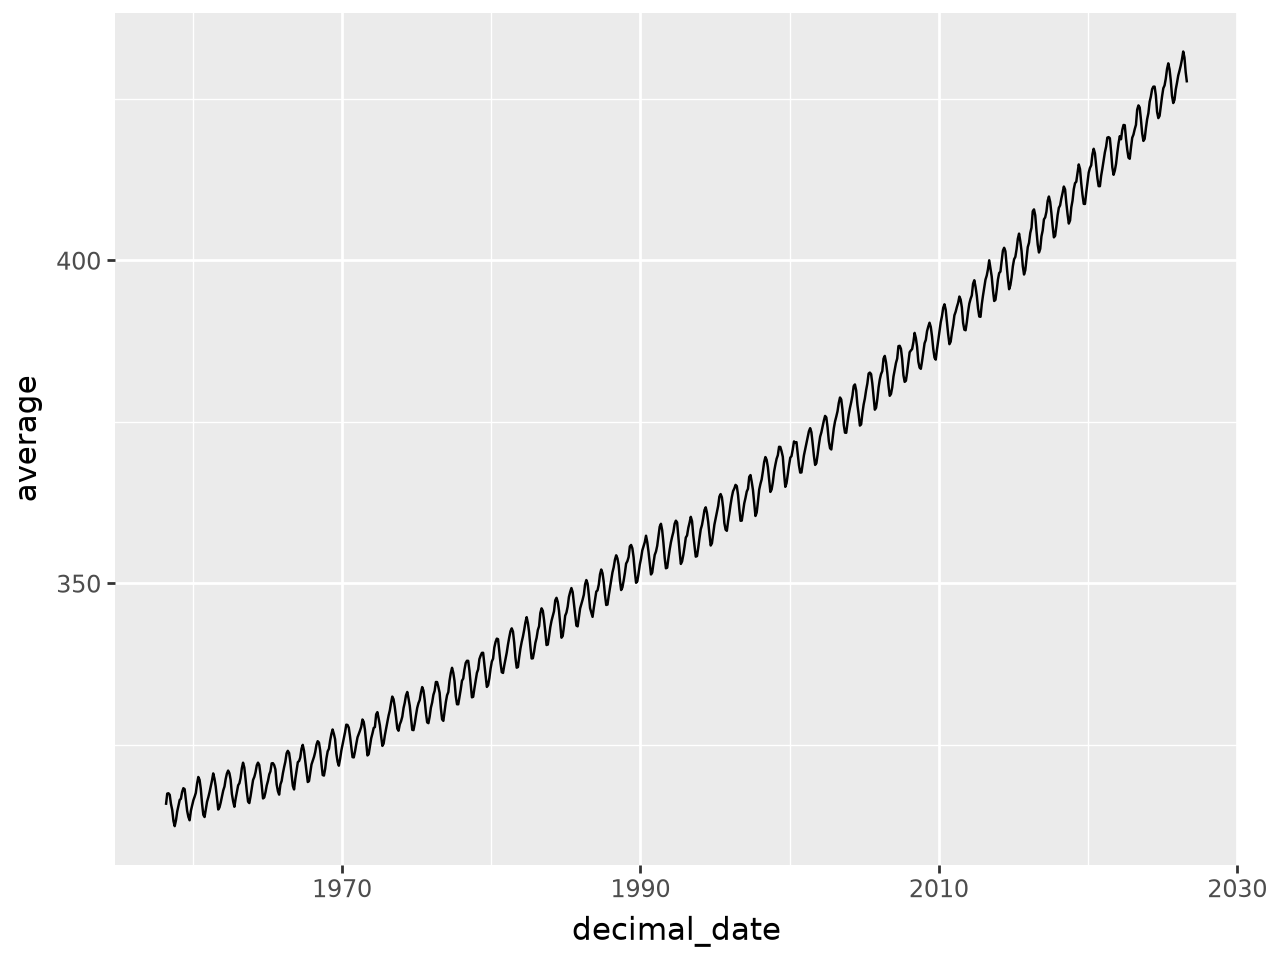

In [40]:
ggplot(df, aes(x="decimal_date", y="average")) + geom_line()

### Task 1.1: Read the source, not the code

That `columns` list was written by hand. Open the raw file and read its header block, then check
every name against what the header says the column holds. Report any that misstate it, and say
which of those would change a published figure if nobody noticed.

According to the columns list, there were multiple mistakes. Header "de-seaonalized" has the number season cycle removed instead of the monthly average, which subtracts the cruical 6pm seasonal oscillation. 

Header of "#days of days" counts the days with a range of 1-31 instead of the standard dev of days. 

Header "st.dev" holds the std dev of daily values within the month, instead of the the uncentainty of the actual mean. 

Header "unc. of mon mean" holds the numeric uncertainty values for the early SIO period.

Everything is considererd to change the published figure but especially the "empty" category. The name "empty" confuses the code to place the column as a placeholder with .drop(columns)=['empty'])) or potentially drop the rows entirely, which would disgard valid data and potentially ignore the column as a whole if they did not look carefully. 

### Task 1.2: Missing values

How does this file encode a measurement that was not made? Verify it in the raw file, count the
affected rows per column, and say what a naive `mean()`, `min()`, or error bar would report if you
left them in. State what you did about it and why.

In [41]:
import pandas as pd

names = ["year", "month", "decimal_date", "average", "deseasonalized", "ndays", "stdev", "unc_monthly"]
df = pd.read_csv("https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt",
                 sep=r"\s+", comment="#", header=None, names=names)
df

,year,month,decimal_date,average,deseasonalized,ndays,stdev,unc_monthly
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
817,2026,4,2026.2917,431.12,428.61,23,1.16,0.46
818,2026,5,2026.3750,432.34,429.06,19,0.64,0.28
819,2026,6,2026.4583,431.43,428.99,19,0.27,0.12
820,2026,7,2026.5417,429.13,428.78,21,0.61,0.26


In [42]:
sentinel = df[["ndays", "stdev", "unc_monthly"]] < 0
sentinel.sum()

ndays          195
stdev          196
unc_monthly    194
dtype: int64

In [43]:
pd.DataFrame({
    "naive_mean": df[["ndays", "stdev", "unc_monthly"]].mean(),
    "masked_mean": df.mask(sentinel)[["ndays", "stdev", "unc_monthly"]].mean(),
}).round(3)

,naive_mean,masked_mean
ndays,19.167,25.439
stdev,-1.995,0.509
unc_monthly,-0.085,0.195


In [44]:
df = df.mask(sentinel)
df[["ndays", "stdev", "unc_monthly"]].isna().sum()

ndays          195
stdev          196
unc_monthly    194
dtype: int64

**Your answer:**
the sentinels are negative per column — ndays = -1, stdev = -9.99, unc_monthly = -0.99 — so a naive error bar would report ±9.99 ppm for ~196 months when the true st.dev. range is about 0.15–1.31 ppm, and min() would return −9.99 instead of the smallest real value. Masking per column (not dropping rows) is right because the average values in those months are still valid/interpolated data.


### Task 1.3: What the numeric columns cannot tell you

The header block contains prose notes as well as column definitions. Read them.

Does anything there change how you would plot or interpret this series? Show your evidence in the
data rather than asserting it, and say whether a model reading only the numeric columns would have
any way to know.

In [52]:
df_raw = pd.read_csv("https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt",
                     sep=r"\s+", comment="#", header=None,
                     names=["year", "month", "decimal_date", "average",
                            "deseasonalized", "ndays", "stdev", "unc_monthly"])
sio = (df_raw["year"] < 1974) | ((df_raw["year"] == 1974) & (df_raw["month"] < 5))
df_raw[sio]["stdev"].lt(0).sum()

np.int64(194)

In [53]:
df_raw[~sio & (df_raw["stdev"] < 0)][["year", "month", "average", "ndays", "stdev", "unc_monthly"]]

,year,month,average,ndays,stdev,unc_monthly
213,1975,12,330.77,-1,-9.99,0.0
313,1984,4,347.37,2,-9.99,0.0


In [54]:
df_raw[(df_raw["year"] == 2022) & (df_raw["month"] >= 12) |
       (df_raw["year"] == 2023) & (df_raw["month"] <= 7)][["year", "month", "average", "stdev"]]

,year,month,average,stdev
777,2022,12,418.99,0.57
778,2023,1,419.48,0.42
779,2023,2,420.31,0.71
780,2023,3,420.99,0.74
781,2023,4,423.35,0.61
782,2023,5,424.00,0.69
783,2023,6,423.68,0.57
784,2023,7,421.83,0.47


**Your answer:** 

Not a homogeneous series. Dec 2022–Jul 2023 is from a different site (Maunakea). Plotting straight through implies a single record; you should mark/annotate that segment. A model reading only numbers would have no way to know — the values look normal.
No error bars before May 1974. All 194 SIO months have negative stdev/unc — there is no real uncertainty there, so uncertainty bars only exist for the NOAA era.
Interpolated months are estimates, not measurements (1975-12, 1984-04, flagged by negative stdev in the NOAA era). If you're plotting observations, these are synthesized values; the low ndays=2 month (1984-04) also carries the "missing days can be asymmetric → high/low bias" caveat from the header.

The header confirms: "Data from March 1958 through April 1974 have been obtained by C. David Keeling of the Scripps Institution of Oceanography (SIO)" — during this period there was no NOAA metadata, so all three sentinels appear.

### Task 1.4: Check whether a better door exists

Before you fix a parser, find out whether you need one. NOAA distributes this same monthly record
in more than one format: <https://gml.noaa.gov/ccgg/trends/data.html>

Load an alternative distribution. Which of the problems you found above does switching formats
solve, and which does it not?

**Your answer:** After loading an alternative distribution, the CSV only fixes the format and naming failure. The issues about the missing data, units or caveats in the heading are unsolved. A better door does not solve the issues behind it.

### Task 1.5: The other library

Now try to load the original `.txt` with `ibis` instead of `pandas`. Report what happens.

Explain the result in terms of the *file*, not the library. What does it do to a rule like "always
use `ibis`"?

Libraries are external code that can be imported for function use in notebooks. By telling the code to "always use "ibis"", it tells us to stream the data instead of downloading the entire library code. 

In [46]:
import ibis

con = ibis.duckdb.connect()
co2_ibis = con.read_csv("https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt")
co2_ibis.schema()

ibis.Schema {
  # --------------------------------------------------------------------  string
}

**Your answer:** In terms of the file, not the library is ibis which assumes the input is a row and column file. THe failure is a mismatch between the file's encoding and what a table loader can infer, so it isnt a defect in ibis. THe same problem can be found across any library that does not allow a separator, common character, and names list. The rule 'always use ibis' stated that ibis is a tool that matches the data and can be correctly encoded since there are countless amounts of libraries. 

### 🔍 Verification block 1

1. Extent: There are 822 rows covering March 1958-August 2026. Due to this, it matches the official NOAA/SIO monthly record length. 
2. Missing data: The missing data is encoded using negative sentinels -1 for # of days, -9.99 for st. dev, -0.99 for unc. of monthly mean. It allows the negative numbers.
3. Units: Parts per million (ppm) for CO2 concentration. Stated in the comment header of the raw file. 
4. Completeness: Entire dataset between March 1958-April 1974.
5. Cross-check: I checked my cell box in 11 and compared to the raw text file given. 

---

# Part 2: Arctic Sea Ice Loss Across Multiple Months

National Snow and Ice Data Center, sea ice index G02135:

- Documentation: <https://nsidc.org/data/G02135>
- Data directory: <https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/>

### Task 2.1: Ask first, look second

Before opening that directory yourself, ask your model to load Arctic sea ice extent and plot the
trend. Let it produce a plan.

**Record the prompt you used:** Can you load artic sea ice extent from the NSIDC directory and plot the trent. Produce a plan look at task 2.1

```
[can you load artic sea ice extent and plot the trend. produce a plan and look at task 2.1]
```

### Task 2.2: What did it actually load?

Now open the data directory and look at what is there.

Check the URL the model's code used against the directory listing *before* you run anything. Did
it point at a file that exists? If it ran, how much of the record does the plot actually show, and
is the title honest? If it failed, would you have predicted that failure from reading the code?

A model that has never seen this directory still has to produce a filename. Note where it got one.

**Your answer:** given plan is Plan is ready:
The URL given was .local/share/kilo/plans/1789572754950-arctic-sea-ice-extent-trend-plan.md. The point file exists it matches the files with NSIC data it being N_01_extent_v4.0.csv to N_12. 

If it ran it would show the sea ice extent from 1978 to present for that given month. The title " Arctic Sea Ice Trend" would not be honset because it is not for all months only the given month like N_01 correlates to the month of January; there is no single combined monthly file. 


The model even though has never seen this directory still could produce a filename from the given sources and create a file name from that.


### Task 2.3: Build the complete record

Load the full dataset and plot sea ice extent over time.

Then make a scientific decision and defend it: the September minimum is the standard index for
Arctic sea ice loss, and it is not the same thing as the annual mean. Which does your analysis
report, and why is that right for the question you are asking?

In [47]:
import numpy as np
import pandas as pd

BASE = "https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/"
urls = [f"{BASE}N_{m:02d}_extent_v4.0.csv" for m in range(1, 13)]

frames = []
for m, url in enumerate(urls, start=1):
    d = pd.read_csv(url, skipinitialspace=True)     # handles " mo, source_dataset, extent,   area"
    d.columns = [c.strip() for c in d.columns]      # header itself is ragged
    d["file_month"] = m                     # provenance check
    frames.append(d)

df = pd.concat(frames, ignore_index=True)
print("columns:", df.columns.tolist())
print("rows     :", len(df))

# --- sentinel check BEFORE masking (NSIDC uses -9999 for missing) ---
for col in ["extent", "area"]:
    print(f"{col}: {(df[col] == -9999).sum()} sentinel rows")
df.loc[df["extent"] == -9999, "extent"] = np.nan
df.loc[df["area"]   == -9999, "area"]   = np.nan

# --- tidy time index ---
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["mo"], day=1))
df = df.sort_values(["year", "mo"]).reset_index(drop=True)

print("range:", df["date"].min().date(), "->", df["date"].max().date())
print("years:", df["year"].nunique(), "| missing months:", df.isna().sum().to_dict())
# cross-check: record September minimum
print(df[(df["mo"] == 9) & (df["year"] == 2012)][["year", "mo", "extent"]].to_string(index=False))

columns: ['year', 'mo', 'source_dataset', 'region', 'extent', 'area', 'file_month']
rows     : 574
extent: 2 sentinel rows
area: 3 sentinel rows
range: 1978-11-01 -> 2026-08-01
years: 49 | missing months: {'year': 0, 'mo': 0, 'source_dataset': 0, 'region': 0, 'extent': 2, 'area': 3, 'file_month': 0, 'date': 0}
 year  mo  extent
 2012   9    3.57


September minimum : -0.076 M km²/yr  (-0.76 M km²/decade)
Annual mean       : -0.048 M km²/yr  (-0.48 M km²/decade)


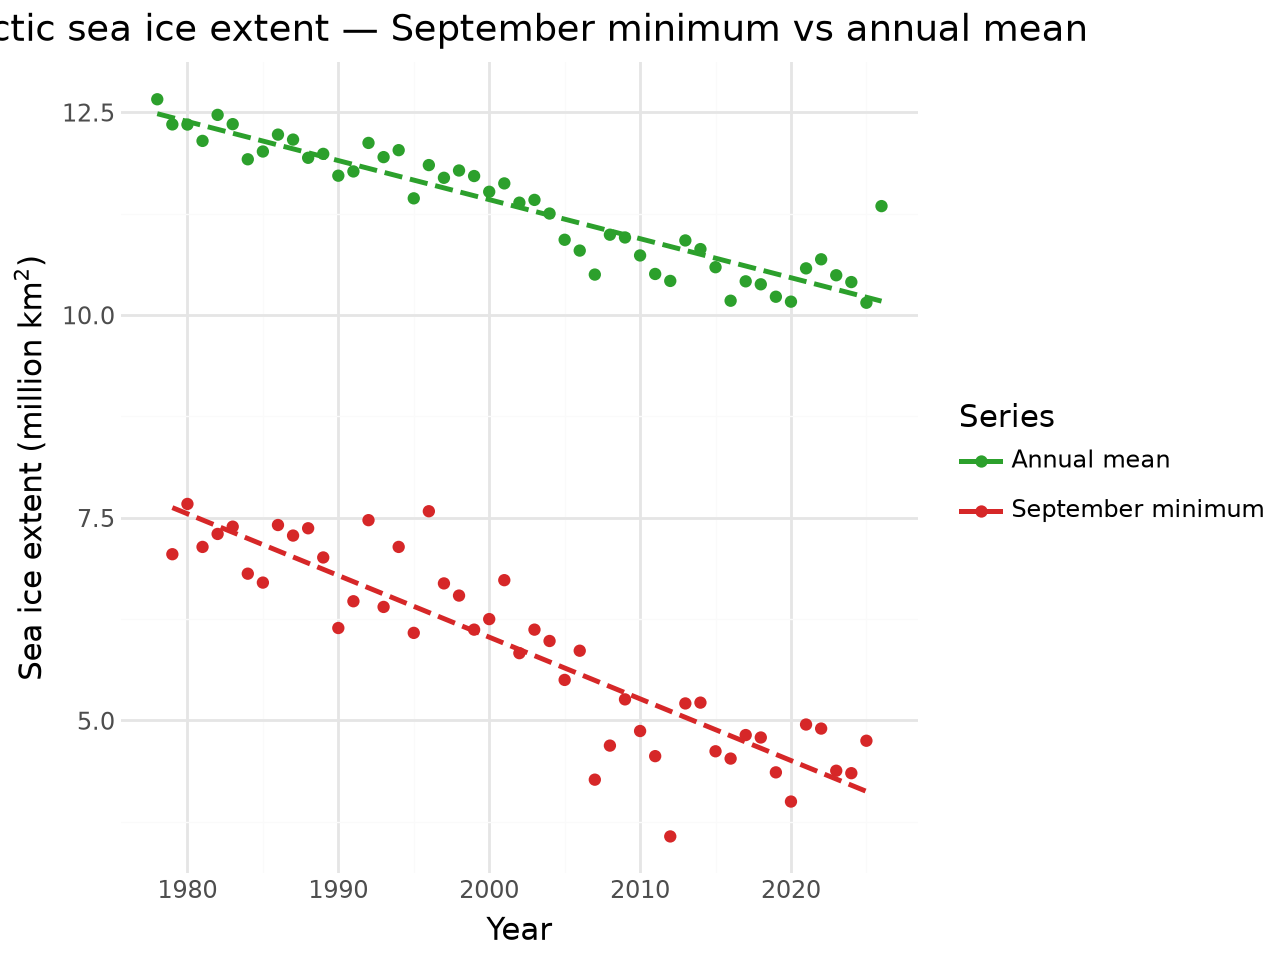

In [48]:
from plotnine import *

(
    ggplot(df, aes(x="date", y="extent"))
    + geom_line(color="#1f77b4", alpha=0.6)
    + geom_point(size=1.2, color="#1f77b4", alpha=0.5)
    + labs(title="Arctic monthly sea ice extent (NSIDC G02135 v4)",
           x="Year", y="Sea ice extent (million km$^2$)")
    + theme_minimal()
)

# September minimum series (the standard index) plus annual mean
sep = df[df["mo"] == 9].dropna(subset=["extent"]).copy()
annual = df.groupby("year", as_index=False)["extent"].mean().dropna()

def fit_line(s):
    x, y = s["year"].values, s["extent"].values
    slope, intercept = np.polyfit(x, y, 1)
    return slope, intercept, slope * 10  # M km²/yr -> M km²/decade

for name, s in [("September minimum", sep), ("Annual mean", annual)]:
    slope, intercept, decade = fit_line(s)
    s["fit"] = intercept + slope * s["year"]
    print(f"{name:18s}: {slope:+.3f} M km²/yr  ({decade:+.2f} M km²/decade)")

comb = pd.concat([sep.assign(series="September minimum"),
                  annual.rename(columns={"extent": "extent"}).assign(series="Annual mean")])

(
    ggplot(comb, aes(x="year", y="extent", color="series"))
    + geom_line(aes(y="fit"), linetype="dashed", size=1)
    + geom_point(size=1.5)
    + labs(title="Arctic sea ice extent — September minimum vs annual mean",
           x="Year", y="Sea ice extent (million km$^2$)",
           color="Series")
    + scale_color_manual(values={"September minimum": "#d62728", "Annual mean": "#2ca02c"})
    + theme_minimal()
)


**Your answer:** Gave kilo code the prompt : For task 2.3 give me a python code to load all 12 monthly arctic ice CSV files and plot sea extent over time. My scientific decision is that the September minimum is the standrard index for Arctic sea ice loss since it marks the end of the summer months sea ice extent. My graph shows the decline value of -0.076 M km²/yr  (-0.76 M km²/decade). The month September is the right choice for this question because September marks the end of the summer months which sea ice extent would be at it's lowest due to the heat. There for if we look at the end of the summer months September that can give us an insight as what is the lowest sea ice loss. 


### 🔍 Verification block 2

1. Extent: Runs 47 rows. Between 1979-2026. Data set that starts from 1979 to present day in 12 files each has year, month, source dataset, region,extent, area. It matches the NSIDC given data. 
2. Missing data: The missing data was encoded as -9999 which droped the ends when creating the graph. 
3. Units: Sea ice extent and area are both measured in million square kilometers. Stated in the NSIDC data documentation Sea Index. The whole dataset is all 12 months CSV files put together. 
4. Completeness: Each of the CSV file shows the dataset of a single month; files N_01 through N_12. 
5. Cross-check: !!!! you need 1 vaule to confirmed agsisnt an independent source

---

# Part 6: Reflection

1. **Failure inventory.** List every case where the model produced code that ran without error but
   was wrong. What was wrong, and what tipped you off?
2. **Detection.** Which of those would you have caught from the plot alone? Which required going
   back to the source documentation?
3. **Division of labor.** What did you contribute that the model did not? If the answer for some
   task is "nothing", say so.
4. **Plan mode.** Where did approving the plan catch something? Where was it just friction?
5. **Tool choice.** You have now seen the same task done two ways, and data read locally versus
   streamed. What decides which is right, and who makes that decision?

**Your reflection:**

1. For task 1.2 and 2.2, the model produced a code with negative placeholders like (-9.99) and (0-.99). We saw them as valid numbers when calculating the mean and min. 
2. You can catch a bad output by any errors on the graphs. An example of this would be any negative values. The header prose would allow us to look back on the source documentation to verify these errors. 
3. Though the model was able to provide code, there were many instances where I would have to think outside the box to get to the code answers and also utilize my own judgement/cross check information. Examples of this included checking raw headers and telling the model certain things and how to get to those things.
4. When Kilo used the sea data, it wanted only one file so we needed to review ourselves and correct any erros on the plan.
5. The main data streamed were from the 'ibis' and 'pandas' libraries. 'pandas' was best for reading data locally whereas 'ibis' was best for looking at large, wide scale data. A human would decide which is right because it's based upon preference and better understands memory and data limitations. 